# Poisson Equation on Triangulated Meshes

On a graph/mesh discretization, a Poisson problem can be written as
$$
L u = f,
$$
with fixed boundary values. This notebook demonstrates harmonic/Poisson solves on a 2D triangulated square.


## Environment

We load numerical tools and define a notebook-local output directory for generated figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/poisson-meshes") if Path("python/poisson-meshes").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Numerical Experiment

We implement the core algorithm and generate comparative visuals to expose behavior clearly.


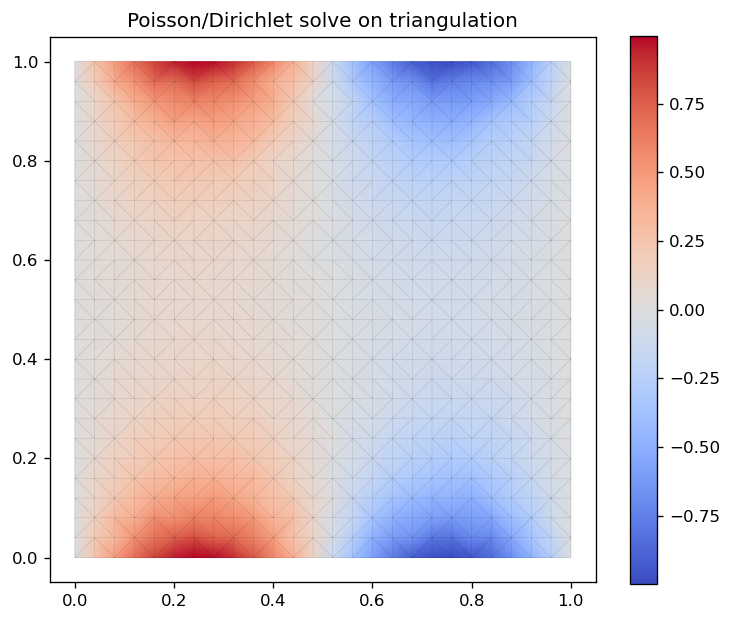

In [2]:
import matplotlib.tri as mtri

m = 26
xx = np.linspace(0, 1, m)
yy = np.linspace(0, 1, m)
X, Y = np.meshgrid(xx, yy)
pts = np.c_[X.ravel(), Y.ravel()]
tri = mtri.Triangulation(pts[:,0], pts[:,1])
N = len(pts)

bnd = (np.isclose(pts[:,0],0) | np.isclose(pts[:,0],1) | np.isclose(pts[:,1],0) | np.isclose(pts[:,1],1))

adj = [set() for _ in range(N)]
for t in tri.triangles:
    for i in range(3):
        a=t[i]
        b=t[(i+1)%3]
        c=t[(i+2)%3]
        adj[a].add(b); adj[a].add(c)

L = np.zeros((N, N))
for i in range(N):
    if bnd[i]:
        L[i, i] = 1.0
    else:
        ng = sorted(adj[i])
        L[i, i] = len(ng)
        for j in ng:
            L[i, j] = -1.0

u_bc = np.sin(2*np.pi*pts[:,0]) * (bnd.astype(float))
f = np.zeros(N)
rhs = f.copy()
rhs[bnd] = u_bc[bnd]
u = np.linalg.solve(L, rhs)

fig, ax = plt.subplots(figsize=(6.3, 5.2))
tpc = ax.tripcolor(tri, u, shading="gouraud", cmap="coolwarm")
ax.triplot(tri, color="k", lw=0.15, alpha=0.3)
ax.set_aspect("equal"); ax.set_title("Poisson/Dirichlet solve on triangulation")
fig.colorbar(tpc, ax=ax)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- M. Meyer, M. Desbrun, P. Schröder, A. H. Barr, "Discrete Differential-Geometry Operators for Triangulated 2-Manifolds", 2002.
- K. Crane, U. Pinkall, P. Schröder, "Spin Transformations of Discrete Surfaces", ACM TOG, 2011.
- M. Botsch et al., *Polygon Mesh Processing*, AK Peters, 2010.
